In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# === 설정: samples 파일이 있는 디렉터리 ===
download_dir = Path('/Users/gim-yonghyeon/Downloads')

# === 데이터 저장용 디렉터리 설정 ===
data_output_dir = Path('./ecg_data')
data_output_dir.mkdir(exist_ok=True)

# === dtype 리스트 ===
dtypes = {
    'int8': np.int8,
    'uint8': np.uint8,
    'int16': np.int16,
    'uint16': np.uint16,
    'int32': np.int32,
    'uint32': np.uint32,
    'float32': np.float32,
}

# 모든 .samples 파일 순회
for file_path in download_dir.glob('*.ecg'):
    print(f"Processing file: {file_path.name}")
    for name, dt in dtypes.items():
        # 파일 읽기
        data = np.fromfile(str(file_path), dtype=dt)
        print(data)
        # 시각화
        # plt.figure()
        # plt.plot(data)
        # plt.title(f'{file_path.name} - dtype: {name}')
        # plt.xlabel('Sample Index')
        # plt.ylabel('Amplitude')
        # plt.tight_layout()
        # plt.show()
        
        # 데이터 저장
        # csv_filename = f'{file_path.stem}_{name}.csv'
        # csv_path = data_output_dir / csv_filename
        # pd.DataFrame(data, columns=['ecg_amplitude']).to_csv(csv_path, index=False)
        # print(f"Data saved to: {csv_path}")

Processing file: 20250513004704_20250513004841.ecg
[   0    6   52 ...   -1   -2 -119]
[  0   6  52 ... 255 254 137]
[  1536  -1740 -30779 ...  12993     -1 -30210]
[ 1536 63796 34757 ... 12993 65535 35326]
[ -114031104   432506821 -1929379840 ...  -114031104   851523275
 -1979777025]
[4180936192  432506821 2365587456 ... 4180936192  851523275 2315190271]
[-5.8420946e+34  2.0630955e-23 -3.9443045e-31 ... -5.8420946e+34
  2.2493074e-08 -6.1389013e-33]
Processing file: 20250513005129_20250513005205.ecg
[ 0  6 52 ... -1 -1 74]
[  0   6  52 ... 255 255  74]
[ 1536 -1740 21461 ...  4530    -1 19199]
[ 1536 63796 21461 ...  4530 65535 19199]
[-114031104 -586853419 -671088641 ... -114031104  296908503 1258291199]
[4180936192 3708113877 3623878655 ... 4180936192  296908503 1258291199]
[-5.8420946e+34 -6.0045354e+17 -5.6294992e+14 ... -5.8420946e+34
  2.8156689e-28  8.3886075e+06]


In [7]:
data

array([-5.8420946e+34, -6.0045354e+17, -5.6294992e+14, ...,
       -5.8420946e+34,  2.8156689e-28,  8.3886075e+06], dtype=float32)

In [8]:
data.shape

(14016,)

In [10]:
print(data[10])

1.648098e-37


In [11]:
len(data[10])

TypeError: object of type 'numpy.float32' has no len()

In [19]:
"%.146f"%data[10]

'0.00000000000000000000000000000000000016480979524586325030889586849581027401536042356036914825104666641850288677506597423416678793728351593017578125'

In [22]:
"%.146f"%data[10]

'0.00000000000000000000000000000000000016480979524586325030889586849581027401536042356036914825104666641850288677506597423416678793728351593017578125'

샘플 개수: 91980
값 범위: 0.0 ~ 255.0
평균/표준편차: 135.17 / 101.32


/var/folders/sj/_83zpf2x3v9bp43rkdkc2bl00000gn/T/ipykernel_22075/3092028980.py:30: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/sj/_83zpf2x3v9bp43rkdkc2bl00000gn/T/ipykernel_22075/3092028980.py:30: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/sj/_83zpf2x3v9bp43rkdkc2bl00000gn/T/ipykernel_22075/3092028980.py:30: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/sj/_83zpf2x3v9bp43rkdkc2bl00000gn/T/ipykernel_22075/3092028980.py:30: UserWarning: Glyph 45937 (\N{HANGUL SYLLABLE DEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/sj/_83zpf2x3v9bp43rkdkc2bl00000gn/T/ipykernel_22075/3092028980.py:30: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


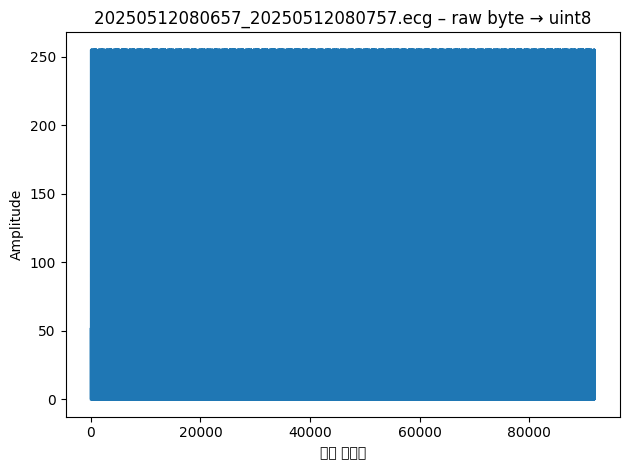

녹음 길이: 60.00초
계산된 샘플링 주파수: 1533.00 Hz


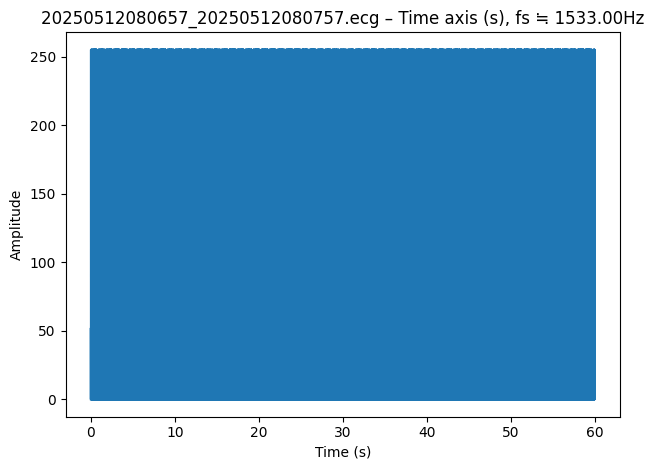

Data saved to: ecg_data/20250512080657_20250512080757_uint8.csv


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime  # 추가

# === 설정: 처리할 파일 ===
file_path = Path('/Users/gim-yonghyeon/Downloads/20250512080657_20250512080757.ecg')

# === 데이터 저장용 디렉터리 ===
data_output_dir = Path('./ecg_data')
data_output_dir.mkdir(exist_ok=True)

# 1) 바이너리로 읽기
raw_bytes = file_path.read_bytes()
data = np.frombuffer(raw_bytes, dtype=np.uint8).astype(np.float32)

# 2) 요약 정보
sample_count = data.size
print(f"샘플 개수: {sample_count}")
print(f"값 범위: {data.min()} ~ {data.max()}")
print(f"평균/표준편차: {data.mean():.2f} / {data.std():.2f}")

# 3) 시각화 (샘플 인덱스 기준)
plt.figure()
plt.plot(data)
plt.title(f'{file_path.name} – raw byte → uint8')
plt.xlabel('샘플 인덱스')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

# === 시간축 계산을 위한 파일명 파싱 ===
# 예: '20250512071603_20250512071730.samples'
file_timerange = Path('/Users/gim-yonghyeon/Downloads/20250512080657_20250512080757.samples')
start_str, end_str = file_timerange.stem.split('_')
t0 = datetime.strptime(start_str, '%Y%m%d%H%M%S')
t1 = datetime.strptime(end_str,   '%Y%m%d%H%M%S')
duration = (t1 - t0).total_seconds()
print(f"녹음 길이: {duration:.2f}초")

# 4) 자동으로 fs 계산
fs = sample_count / duration
print(f"계산된 샘플링 주파수: {fs:.2f} Hz")

# 5) 시간축(초)로 시각화
t = np.linspace(0, duration, sample_count)
plt.figure()
plt.plot(t, data)
plt.title(f'{file_path.name} – Time axis (s), fs ≒ {fs:.2f}Hz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

# 6) CSV로 저장
csv_path = data_output_dir / f'{file_path.stem}_uint8.csv'
pd.DataFrame(data, columns=['ecg_amplitude']).to_csv(csv_path, index=False)
print(f"Data saved to: {csv_path}")

Processing file: 20250512080924_20250512080928.samples
[ 0 68 68 68]


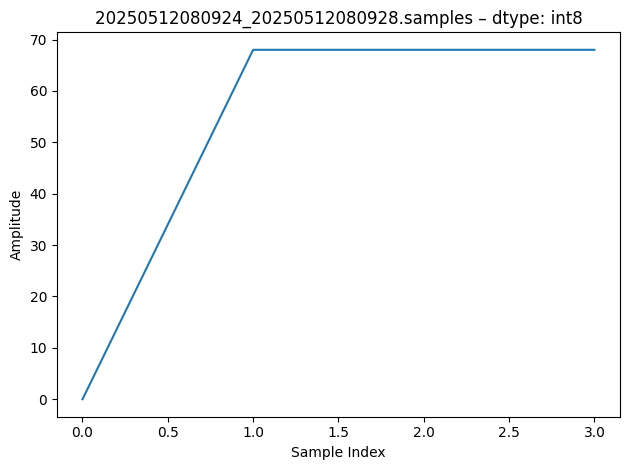

[ 0 68 68 68]


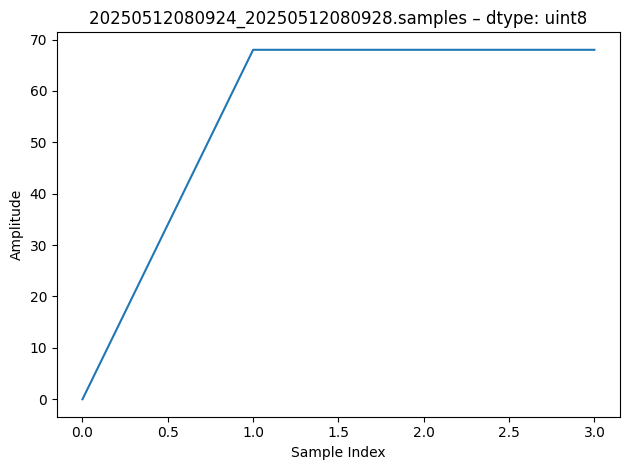

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# === 설정: 처리할 단일 .samples 파일 경로 지정 ===
file_path = Path('/Users/gim-yonghyeon/Downloads/20250512080924_20250512080928.samples')

# === 데이터 저장용 디렉터리 설정 ===
data_output_dir = Path('./ecg_data')
data_output_dir.mkdir(exist_ok=True)

# === dtype 리스트 ===
dtypes = {'int8': np.int8, 'uint8': np.uint8}

# 단일 파일 처리
print(f"Processing file: {file_path.name}")
for name, dt in dtypes.items():
    # 파일 읽기
    data = np.fromfile(str(file_path), dtype=dt)  # numpy.fromfile 사용법: https://numpy.org/doc/stable/reference/generated/numpy.fromfile.html :contentReference[oaicite:0]{index=0}

    print(data)

    # 시각화
    plt.figure()
    plt.plot(data)
    plt.title(f'{file_path.name} – dtype: {name}')
    plt.xlabel('Sample Index')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    plt.show()

    # 데이터 저장
    csv_filename = f'{file_path.stem}_{name}.csv'
    csv_path = data_output_dir /_
